In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [30]:
class AgentState(TypedDict):
    message: str
    
def greeting_node(state: AgentState) -> AgentState:
    """Simple node that generates a greeting message to the state"""
    state['message'] = 'Hey ' + state['message'] + ",how was your day?"
    
    return state

def compliment_agent(state: AgentState) -> AgentState:
    """Simple node that can generate an gives the user a compliment"""
    state['message'] = state['message'] + "you're doing an amazing job learning LangGraph!"
    return state

In [31]:
graph = StateGraph(AgentState)

graph.add_node('greeter', greeting_node)
graph.add_node('complimentary', compliment_agent)
graph.add_edge('greeter', 'complimentary')
graph.set_entry_point('greeter')
graph.set_finish_point('complimentary')

app = graph.compile()

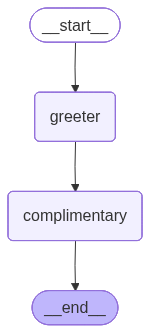

In [32]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [33]:
result = app.invoke({'message': 'Dinesh'})


In [34]:
result['message']

"Hey Dinesh,how was your day?you're doing an amazing job learning LangGraph!"